# Large Dataset Processing

Some of our collected datasets yield a stiched geotif image larger than 1GB. This makes some of our CV techniques impractical to perform, and we quickly hit memory and computation constraints. 

This notebook will explore techniques to handle these sets gracefully, even on limited hardware.

Some techniques to explore:
- Tiling
- Multi-resolution analysis
- Streaming/chunk-based processing
- Dimensionality reduction

In [1]:
# Load required libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from skimage.filters import threshold_otsu
from skimage.color import rgb2lab
from scipy.ndimage import gaussian_filter, label
import rasterio
from rasterio.plot import show
from PIL import Image
from ipywidgets import interact, FloatSlider
import os
import sys
from pathlib import Path

# Add the parent directory to the Python path
# So we can find local modules e.g. "plant_search"
sys.path.append(str(Path.cwd().parent))

%matplotlib inline

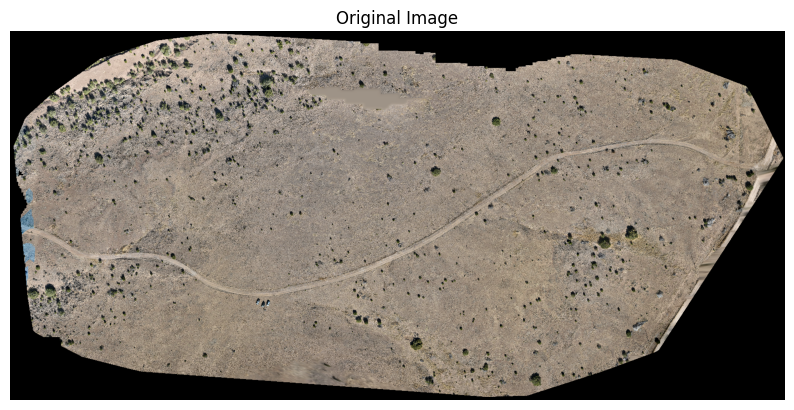

Scaled image dimensions: (809, 1701, 3)


In [2]:
from plant_search.load_image import load_image, plot_image


# file_path = 'input/ESPG-4326-orthophoto.tif'
# file_path = 'input/MADRID_RGB.tif'
# file_path = '../input/aerial-trees.jpg'

# file_path = '../input/DJI_0010.JPG'
# file_path = '../input/DJI_0015.JPG'
# file_path = '../input/DJI_0093.JPG'
# file_path = '../input/DJI_0119.JPG'
file_path = '../input/IGNORE_Brewster-ortho.tif'

ds = 8 # downscale ratio

image = load_image(file_path)
if image is not None:
    image = image[::ds, ::ds]
    plot_image(image, "Original Image")

print(f"Scaled image dimensions: {image.shape}")

## Tiling

- Tile overlapping
- Merging overlapping regions
- Handle partial detection
- Global stitching

In [5]:
import rasterio
from rasterio.windows import Window
import os
from pathlib import Path
from matplotlib.patches import Rectangle

def tile_geotiff(input_path, output_dir, tile_size, overlap=0):
    """
    Splits a GeoTIFF into tiles of specified size with optional overlap and saves them to the output directory.

    Args:
    - input_path (str): Path to the input GeoTIFF file.
    - output_dir (str): Directory where the tiles will be saved.
    - tile_size (int): Size of each tile in pixels (tile_size x tile_size).
    - overlap (int): Number of pixels to overlap between adjacent tiles (default is 0).
    """
    # Create output directory if it doesn't exist
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    # Open the input GeoTIFF
    with rasterio.open(input_path) as src:
        width, height = src.width, src.height
        print(f"Source dimensions: {width}x{height}")
        
        # Iterate over the GeoTIFF to create tiles
        for y in range(0, height, tile_size - overlap):
            for x in range(0, width, tile_size - overlap):
                # Define the window for the tile
                window = Window(x, y, tile_size, tile_size)
                transform = src.window_transform(window)
                
                # Ensure window does not exceed image bounds
                tile_width = min(tile_size, width - x)
                tile_height = min(tile_size, height - y)
                tile_window = Window(x, y, tile_width, tile_height)
                
                # Read the tile data
                tile_data = src.read(window=tile_window)
                
                # Construct tile filename
                tile_filename = f"tile_{x}_{y}.tif"
                tile_path = os.path.join(output_dir, tile_filename)
                
                # Save the tile
                with rasterio.open(
                    tile_path,
                    'w',
                    driver='GTiff',
                    height=tile_data.shape[1],
                    width=tile_data.shape[2],
                    count=src.count,
                    dtype=tile_data.dtype,
                    crs=src.crs,
                    transform=src.window_transform(tile_window),
                ) as dst:
                    dst.write(tile_data)
                print(f"Saved tile: {tile_path}")

    print(f"Tiling complete. Tiles saved to {output_dir}.")


def visualize_tiles(input_path, tile_size, overlap=0):
    """
    Visualizes the tiles on the original GeoTIFF by overlaying red rectangles
    showing the tile positions.
    
    Args:
    - input_path (str): Path to the input GeoTIFF file.
    - tile_size (int): Size of each tile in pixels (tile_size x tile_size).
    - overlap (int): Number of pixels to overlap between adjacent tiles (default is 0).
    """
    with rasterio.open(input_path) as src:
        width, height = src.width, src.height
        print(f"Source dimensions: {width}x{height}")
        
        # Plot the original image
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.invert_yaxis()
        show(src, ax=ax, title="Tile Visualization with Red Squares", with_bounds=False)
        
        # print(f"x-axis limits: {ax.get_xlim()}")
        # print(f"y-axis limits: {ax.get_ylim()}")

        num_tiles = 0
        # Iterate over tiles and draw rectangles
        for y in range(0, height, tile_size - overlap):
            for x in range(0, width, tile_size - overlap):
                # Ensure the rectangle fits within the image bounds
                tile_width = min(tile_size, width - x)
                tile_height = min(tile_size, height - y)
                
                # Draw a red rectangle for the tile
                rect = Rectangle((x, y), tile_width, tile_height, 
                                 linewidth=1.5, edgecolor='red', facecolor='none')
                # print(f"Drawing rectangle at: x={x}, y={y}, width={tile_width}, height={tile_height}")
                ax.add_patch(rect)
                num_tiles += 1

        print(f"Number of tiles with settings: {num_tiles}")        
        plt.show()

Source dimensions: 13603x6468
Number of tiles with settings: 32


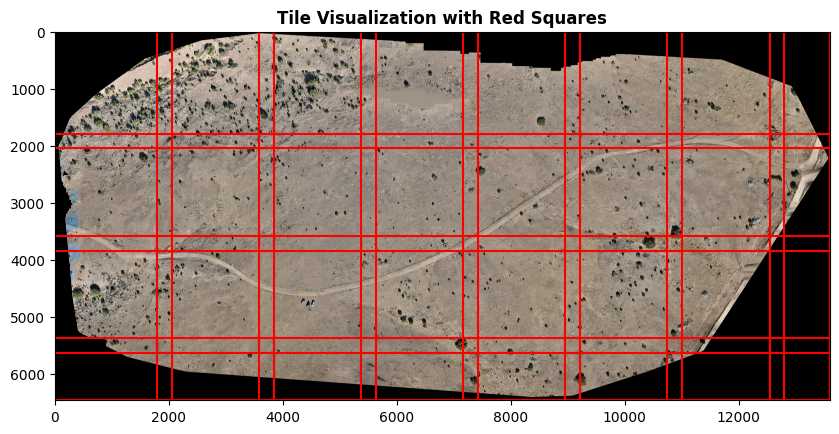

In [6]:
input_geotiff_path = file_path  # Replace with your GeoTIFF path
output_tiles_dir = "../outputs/7_large_datasets/tiling"  # Directory to save tiles
tile_size_pixels = 2048  # Tile size in pixels
overlap_pixels = 256  # Overlap in pixels between tiles

# with rasterio.open(input_geotiff_path) as src:
#     print(f"CRS: {src.crs}")  # Check if the CRS is defined
#     print(f"Transform: {src.transform}")  # Check if the transform is defined

# Use this for debugging: see how many and where tiles will be
visualize_tiles(input_geotiff_path, tile_size_pixels, overlap_pixels)

# Use this to actually generate tiles
# tile_geotiff(input_geotiff_path, output_tiles_dir, tile_size_pixels, overlap_pixels)